In [1]:
import os
print(os.getcwd())

c:\Users\swath\OneDrive\Desktop\Projects\customer-churn-prediction\notebooks


#Telco Churn Analysis

## Dataset Information

The **Telco Customer Churn** dataset contains demographic, service subscription, billing, and account information for telecom customers. The objective is to predict whether a customer is likely to churn. The target variable, **Churn**, indicates whether the customer left the telecom company's services during the previous month.

In [2]:
#import required libraries to perform EDA
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import matplotlib.ticker as mtick



In [3]:
#load the dataset; '..' means go back one directory from the current working directory
df = pd.read_csv('../data/WA_Fn-UseC_-Telco-Customer-Churn.csv')

In [4]:
#to quickly inspect the dataset and ensure it has been loaded correctly
df.head()


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [5]:
#To understand the size of the dataset before performing analysis or building a model.
df.shape

(7043, 21)

In [6]:
df.columns.values

array(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
       'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract',
       'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges',
       'TotalCharges', 'Churn'], dtype=object)

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [8]:
df.dtypes

customerID           object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges         object
Churn                object
dtype: object

In [9]:
#it gives a quick understanding of the distribution of numeric features
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


SeniorCitizen column has categorical so 25%,50%,75% is not proper
75% customers has tenure less than 55 months
The average monthly charges are 64.76 whereas 25% customers pay more than 89.85 monthly 

In [10]:
df['Churn'].value_counts()

Churn
No     5174
Yes    1869
Name: count, dtype: int64

Text(0.5, 1.0, 'Count of Target variable per Category')

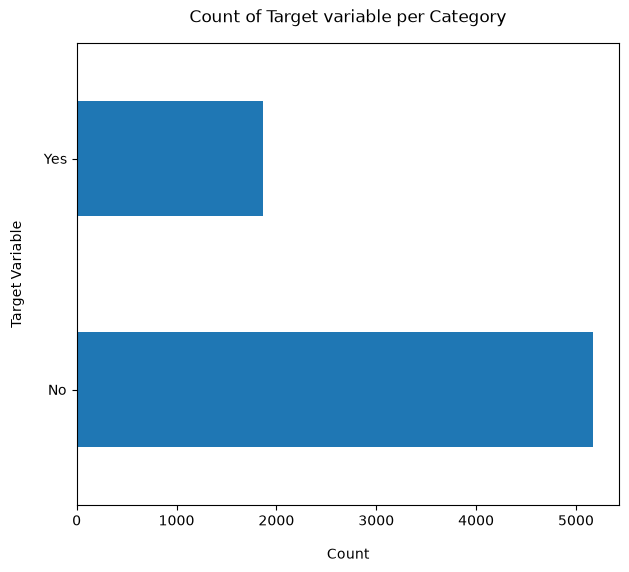

In [11]:
df['Churn'].value_counts().plot(kind='barh',figsize=(7,6))
plt.xlabel("Count",labelpad=14)
plt.ylabel("Target Variable",labelpad=14)
plt.title("Count of Target variable per Category",pad=15)

In [12]:
100*df['Churn'].value_counts()/len(df['Churn'])

Churn
No     73.463013
Yes    26.536987
Name: count, dtype: float64

-> More customers stayed than left, so data is highly imbalanced ,the ratio is 73:27
-> A model that always predict No as output would already acheive a high accuracy, so accuracy alone is not a good evaluation metric
-> So we analyze the data with other features while taking target variable separately to get some insights


In [13]:
telco_data=df.copy()

In [14]:
telco_data.info(verbose=True)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


->"verbose=True" forces pandas to display detailed information for every column. It's especially useful for datasets with many columns, where the default df.info() may summarize or truncate the output
-> Note: Here 'Totalcharges' Column is object

In [15]:
telco_data[telco_data['TotalCharges'].isnull()]


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn


In [16]:
(telco_data['TotalCharges']==' ').sum()

np.int64(11)

In [17]:
telco_data[telco_data['TotalCharges']==' ']

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
488,4472-LVYGI,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,...,Yes,Yes,Yes,No,Two year,Yes,Bank transfer (automatic),52.55,,No
753,3115-CZMZD,Male,0,No,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.25,,No
936,5709-LVOEQ,Female,0,Yes,Yes,0,Yes,No,DSL,Yes,...,Yes,No,Yes,Yes,Two year,No,Mailed check,80.85,,No
1082,4367-NUYAO,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.75,,No
1340,1371-DWPAZ,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,...,Yes,Yes,Yes,No,Two year,No,Credit card (automatic),56.05,,No
3331,7644-OMVMY,Male,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,19.85,,No
3826,3213-VVOLG,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.35,,No
4380,2520-SGTTA,Female,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.00,,No
5218,2923-ARZLG,Male,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,One year,Yes,Mailed check,19.70,,No
6670,4075-WKNIU,Female,0,Yes,Yes,0,Yes,Yes,DSL,No,...,Yes,Yes,Yes,No,Two year,No,Mailed check,73.35,,No


### Observation

- `isnull()` reports no missing values in the `TotalCharges` column. - The column contains **11 blank string values (`" "`)** rather than actual `NaN` values. - Because of these non-numeric entries, pandas inferred the TotalCharges column as object because it contains blank string values (' ') along with numeric values. - The column should be converted to a numeric type using `pd.to_numeric(..., errors='coerce')` so that blank strings become `NaN` and can be handled during data cleaning.

In [18]:
telco_data['TotalCharges']=pd.to_numeric(telco_data['TotalCharges'],errors='coerce')

In [19]:
telco_data.info()
telco_data['TotalCharges'].isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


np.int64(11)

In [20]:
missing_data=pd.DataFrame(telco_data.isnull().sum()*100/telco_data.shape[0]).reset_index()
missing_data.columns=['column_name','missing_percentage']
missing_data

,column_name,missing_percentage
0,customerID,0.000000
1,gender,0.000000
2,SeniorCitizen,0.000000
3,Partner,0.000000
4,Dependents,0.000000
5,tenure,0.000000
6,PhoneService,0.000000
7,MultipleLines,0.000000
8,InternetService,0.000000
9,OnlineSecurity,0.000000


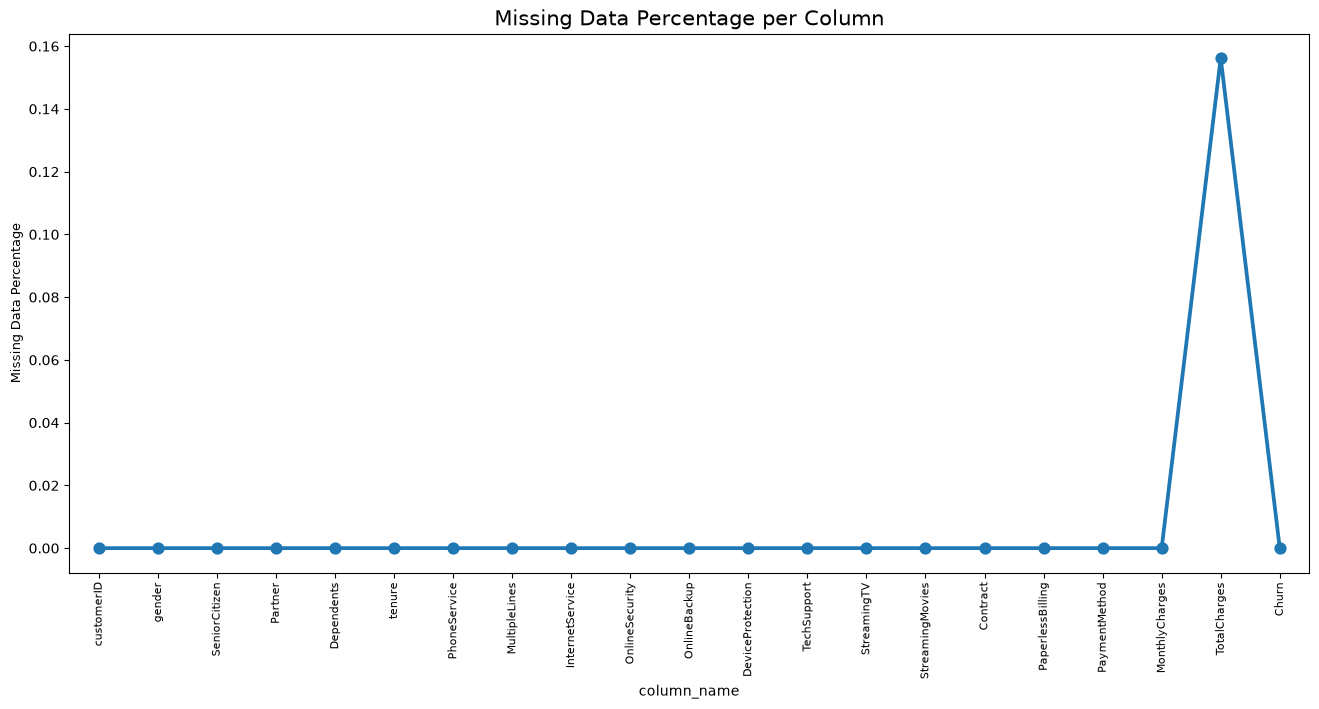

In [21]:
plt.figure(figsize=(16,7))
ax=sns.pointplot(x='column_name',y='missing_percentage',data=missing_data)
plt.xticks(rotation=90,fontsize=8)
plt.ylabel("Missing Data Percentage",fontsize=9)
plt.title("Missing Data Percentage per Column",fontsize=15)
plt.show()


-Since the % of these records compared to total dataset is very low ie 0.15%, it is safe to ignore them from further processing.

In [22]:
#removing missing values from the dataset. Since the number of missing values is very small, we can drop them without losing much information.
telco_data.dropna(how='any',inplace=True)

In [23]:
print(telco_data['tenure'].max())

72


In [24]:
labels=[]
for i in range(1,72,12):
    label="{0}-{1}".format(i,i+11)
    labels.append(label)
print(labels)

['1-12', '13-24', '25-36', '37-48', '49-60', '61-72']


In [25]:
telco_data['tenure_group']=pd.cut(telco_data.tenure,range(1,80,12),right=False,labels=labels)


In [26]:
telco_data['tenure_group'].value_counts()

tenure_group
1-12     2175
61-72    1407
13-24    1024
25-36     832
49-60     832
37-48     762
Name: count, dtype: int64

In [27]:
telco_data.drop(columns=['customerID','tenure'],axis=1,inplace=True)
telco_data.head()

,gender,SeniorCitizen,Partner,Dependents,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,tenure_group
0,Female,0,Yes,No,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No,1-12
1,Male,0,No,No,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No,25-36
2,Male,0,No,No,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,1-12
3,Male,0,No,No,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No,37-48
4,Female,0,No,No,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,1-12


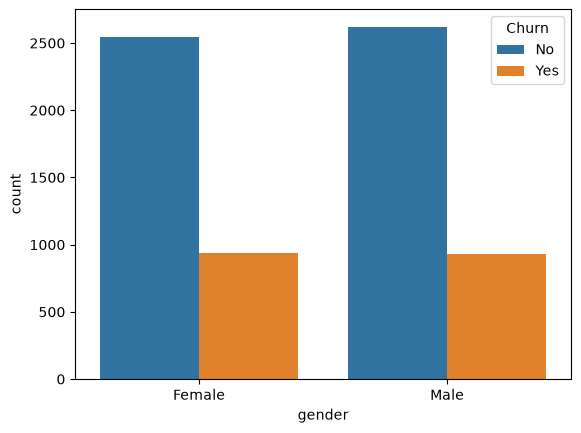

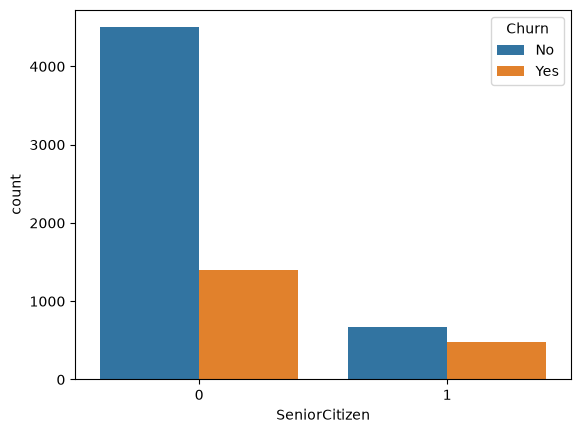

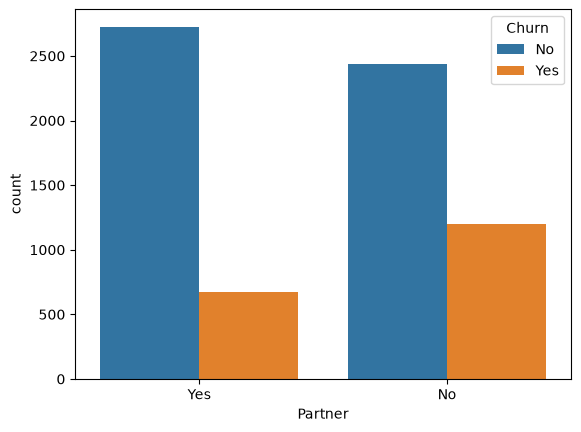

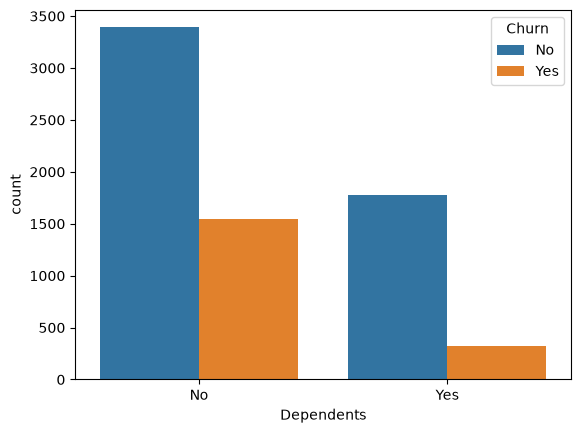

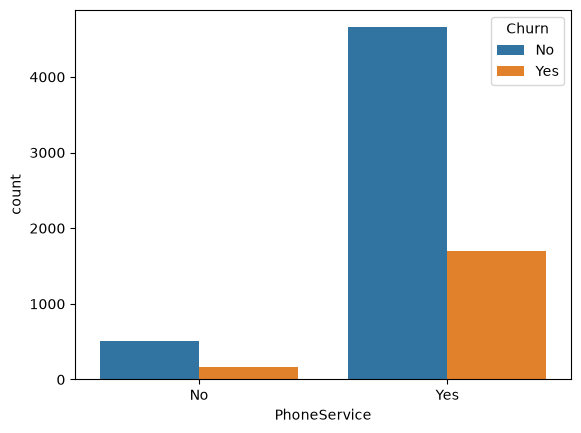

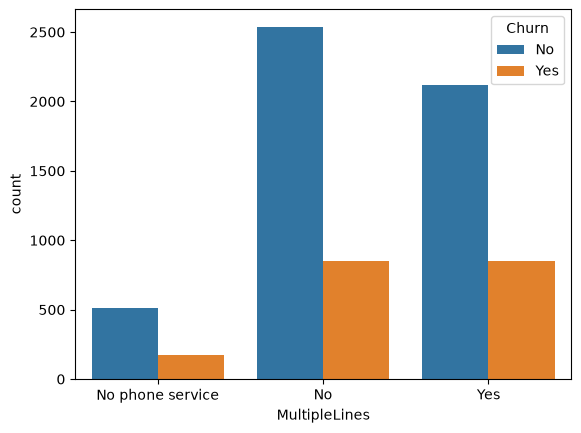

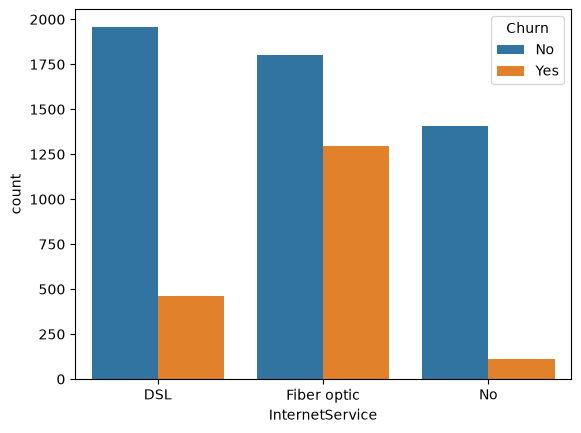

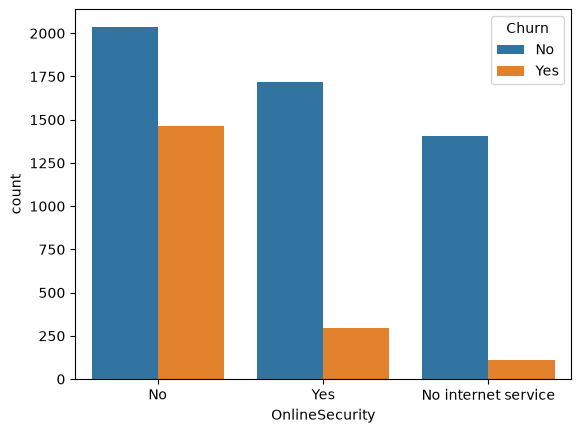

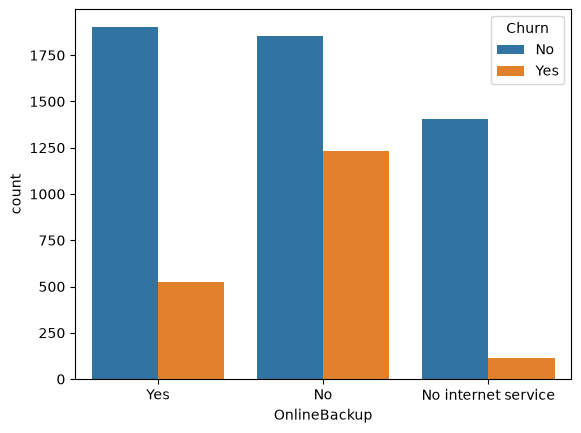

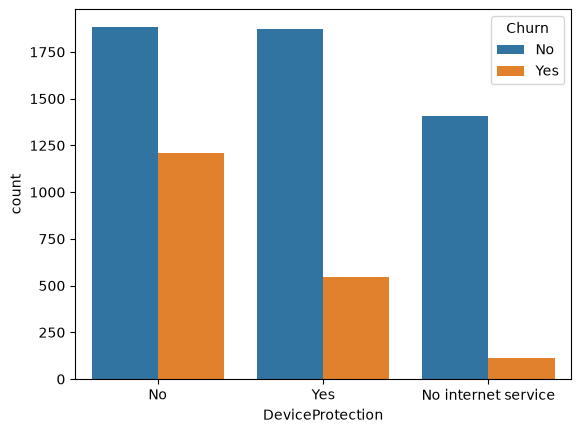

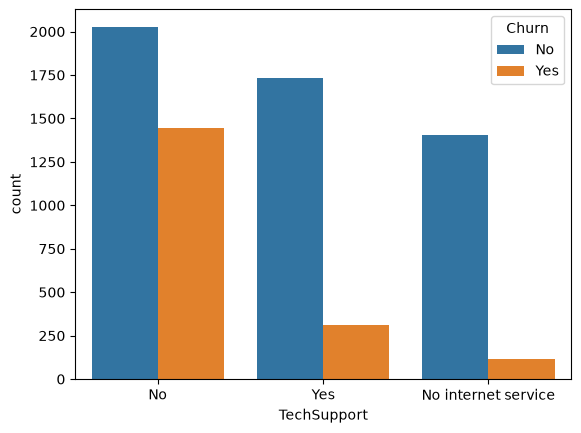

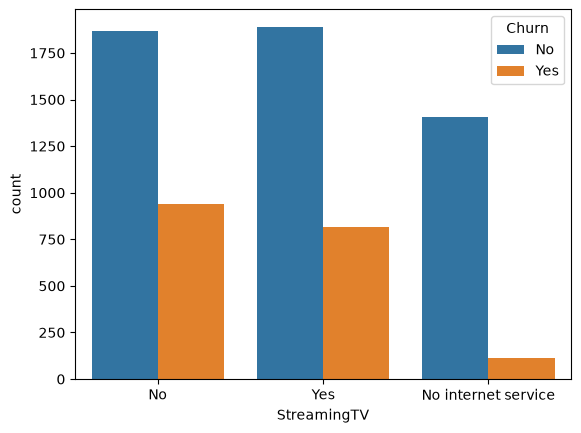

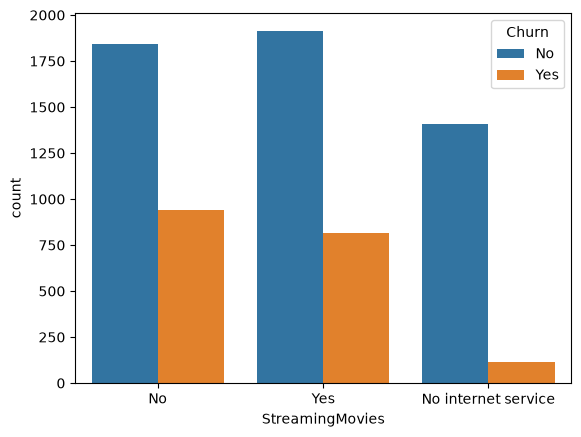

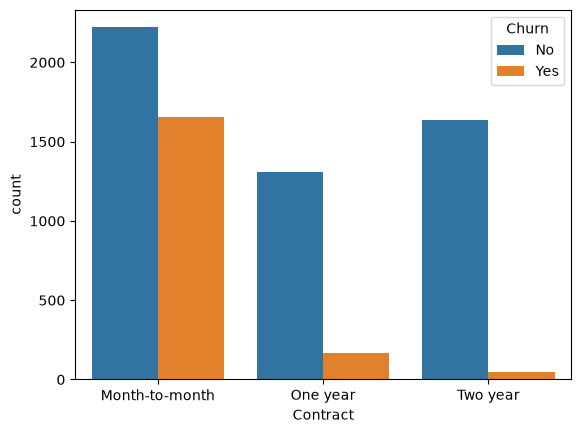

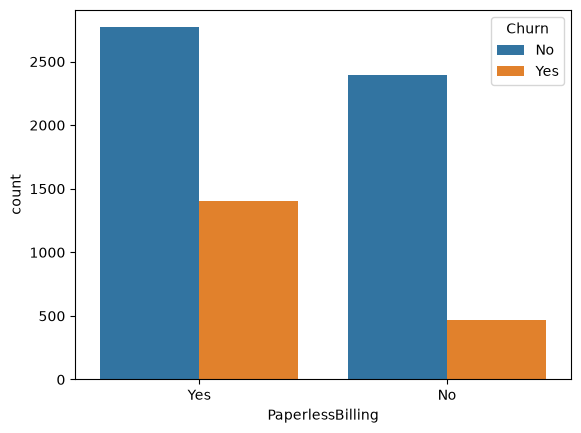

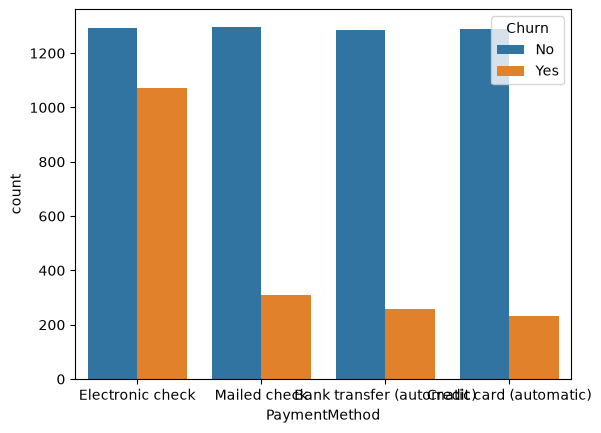

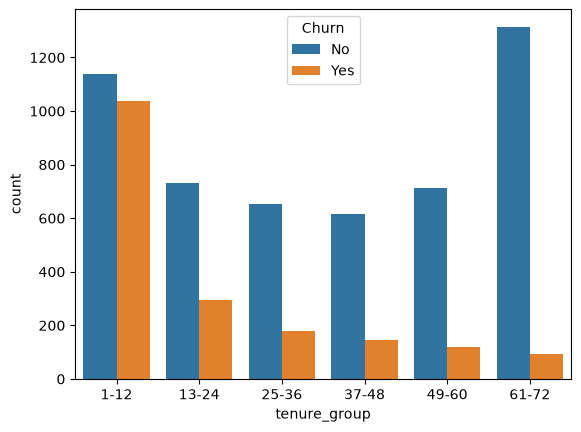

In [28]:
for i , predictor in enumerate(telco_data.drop(columns=['Churn','TotalCharges','MonthlyCharges'])):
    plt.figure(i)
    sns.countplot(x=predictor,data=telco_data,hue='Churn')

In [29]:
telco_data['Churn']=np.where(telco_data['Churn']=='Yes',1,0)

In [30]:
telco_data.head()

,gender,SeniorCitizen,Partner,Dependents,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,tenure_group
0,Female,0,Yes,No,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,0,1-12
1,Male,0,No,No,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,0,25-36
2,Male,0,No,No,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,1,1-12
3,Male,0,No,No,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,0,37-48
4,Female,0,No,No,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,1,1-12


In [31]:
telco_data_dummies=pd.get_dummies(telco_data)
telco_data_dummies.head()

,SeniorCitizen,MonthlyCharges,TotalCharges,Churn,gender_Female,gender_Male,Partner_No,Partner_Yes,Dependents_No,Dependents_Yes,...,PaymentMethod_Bank transfer (automatic),PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check,tenure_group_1-12,tenure_group_13-24,tenure_group_25-36,tenure_group_37-48,tenure_group_49-60,tenure_group_61-72
0,0,29.85,29.85,0,True,False,False,True,True,False,...,False,False,True,False,True,False,False,False,False,False
1,0,56.95,1889.50,0,False,True,True,False,True,False,...,False,False,False,True,False,False,True,False,False,False
2,0,53.85,108.15,1,False,True,True,False,True,False,...,False,False,False,True,True,False,False,False,False,False
3,0,42.30,1840.75,0,False,True,True,False,True,False,...,True,False,False,False,False,False,False,True,False,False
4,0,70.70,151.65,1,True,False,True,False,True,False,...,False,False,True,False,True,False,False,False,False,False


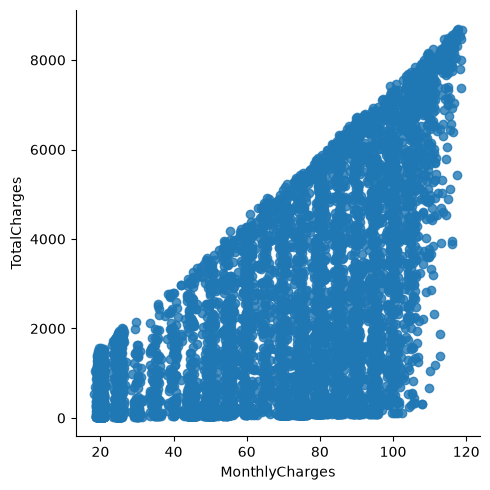

In [32]:
sns.lmplot(data=telco_data_dummies,x='MonthlyCharges',y='TotalCharges',fit_reg=False)

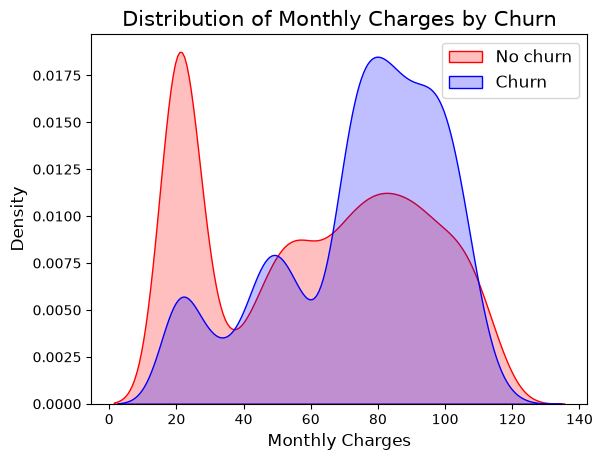

In [35]:
Mth=sns.kdeplot(telco_data_dummies.MonthlyCharges[(telco_data_dummies.Churn==0)],color='Red',fill=True,label='No churn')
Mth=sns.kdeplot((telco_data_dummies.MonthlyCharges[(telco_data_dummies.Churn==1)]),ax=Mth,color='Blue',fill=True,label='Churn')
Mth.set_xlabel("Monthly Charges",fontsize=12)
Mth.set_ylabel("Density",fontsize=12)
Mth.set_title("Distribution of Monthly Charges by Churn",fontsize=15)
Mth.legend(labels=['No churn','Churn'],loc='best',fontsize=12)

Text(0.5, 1.0, 'Distribution of Total Charges by Churn')

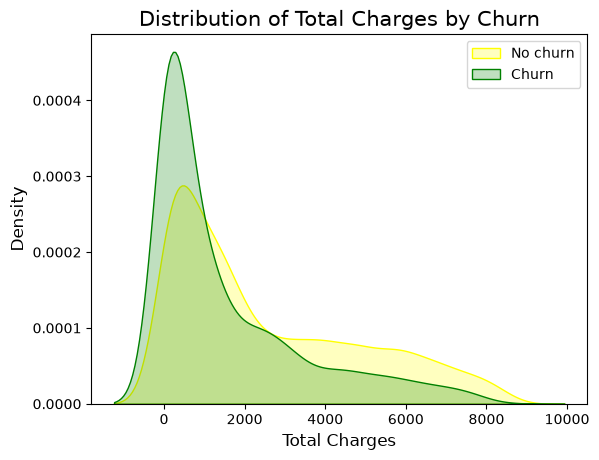

In [38]:
Tch=sns.kdeplot(telco_data_dummies.TotalCharges[(telco_data_dummies.Churn==0)],color="Yellow",fill=True,label='No churn')
Tch=sns.kdeplot(telco_data_dummies.TotalCharges[(telco_data_dummies.Churn==1)],ax=Tch,color='Green',fill=True,label='Churn')
Tch.legend(labels=['No churn','Churn'],loc='best',fontsize=10)
Tch.set_xlabel("Total Charges",fontsize=12)
Tch.set_ylabel("Density",fontsize=12)
Tch.set_title("Distribution of Total Charges by Churn",fontsize=15)

<Axes: >

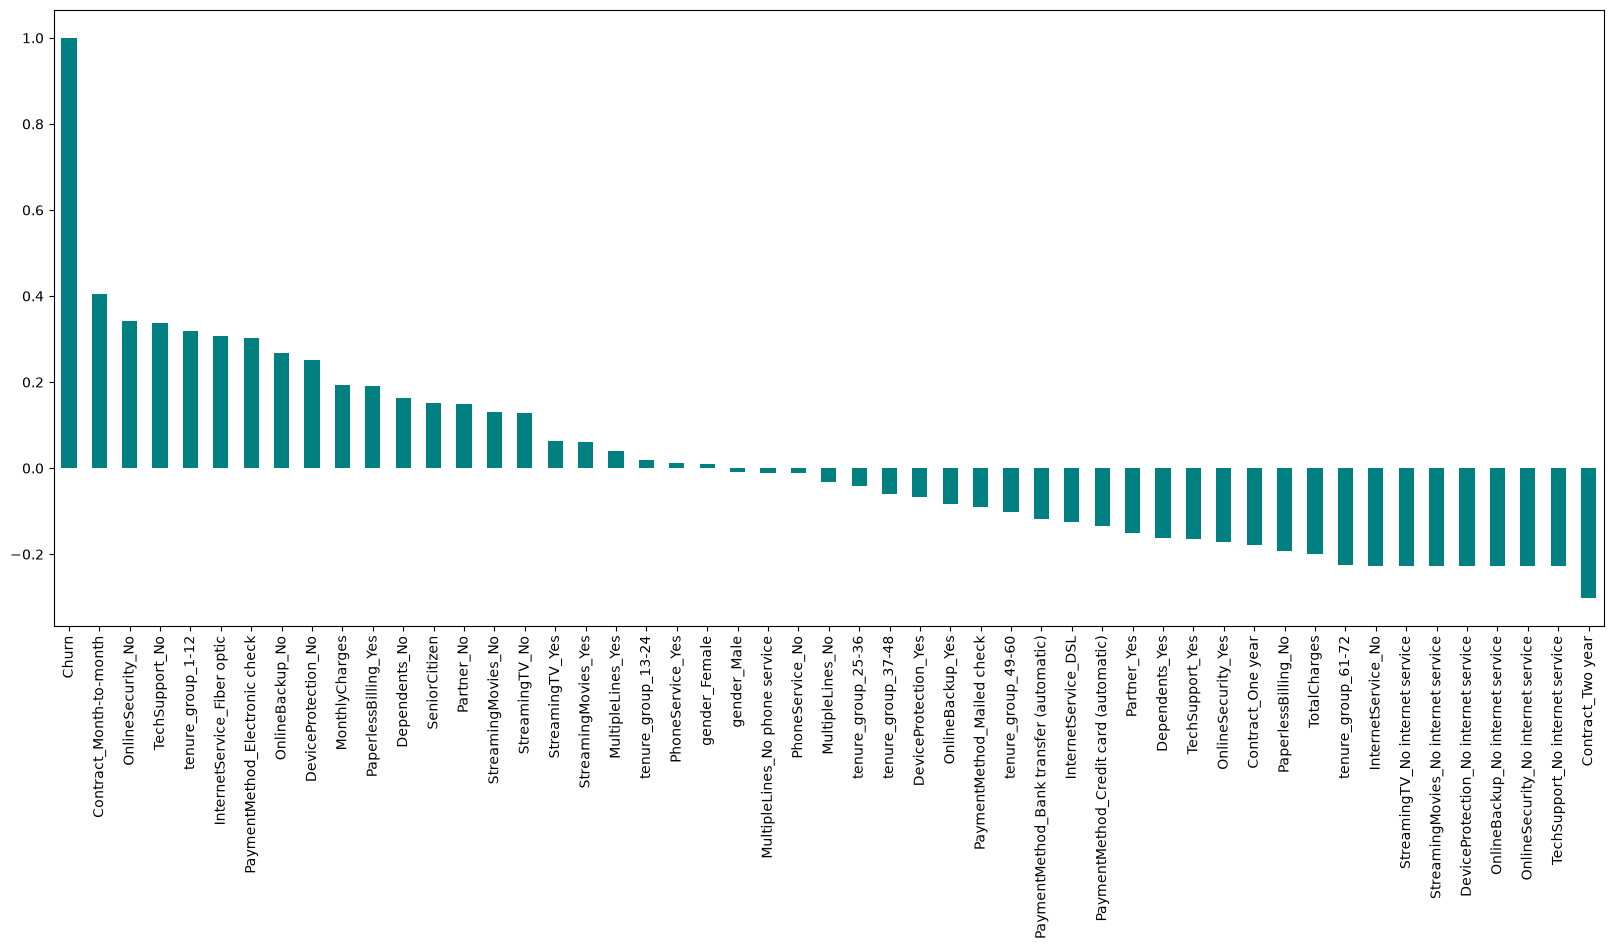

In [44]:
plt.figure(figsize=(20,8))
telco_data_dummies.corr()['Churn'].sort_values(ascending=False).plot(kind='bar',color='teal')

<Axes: >

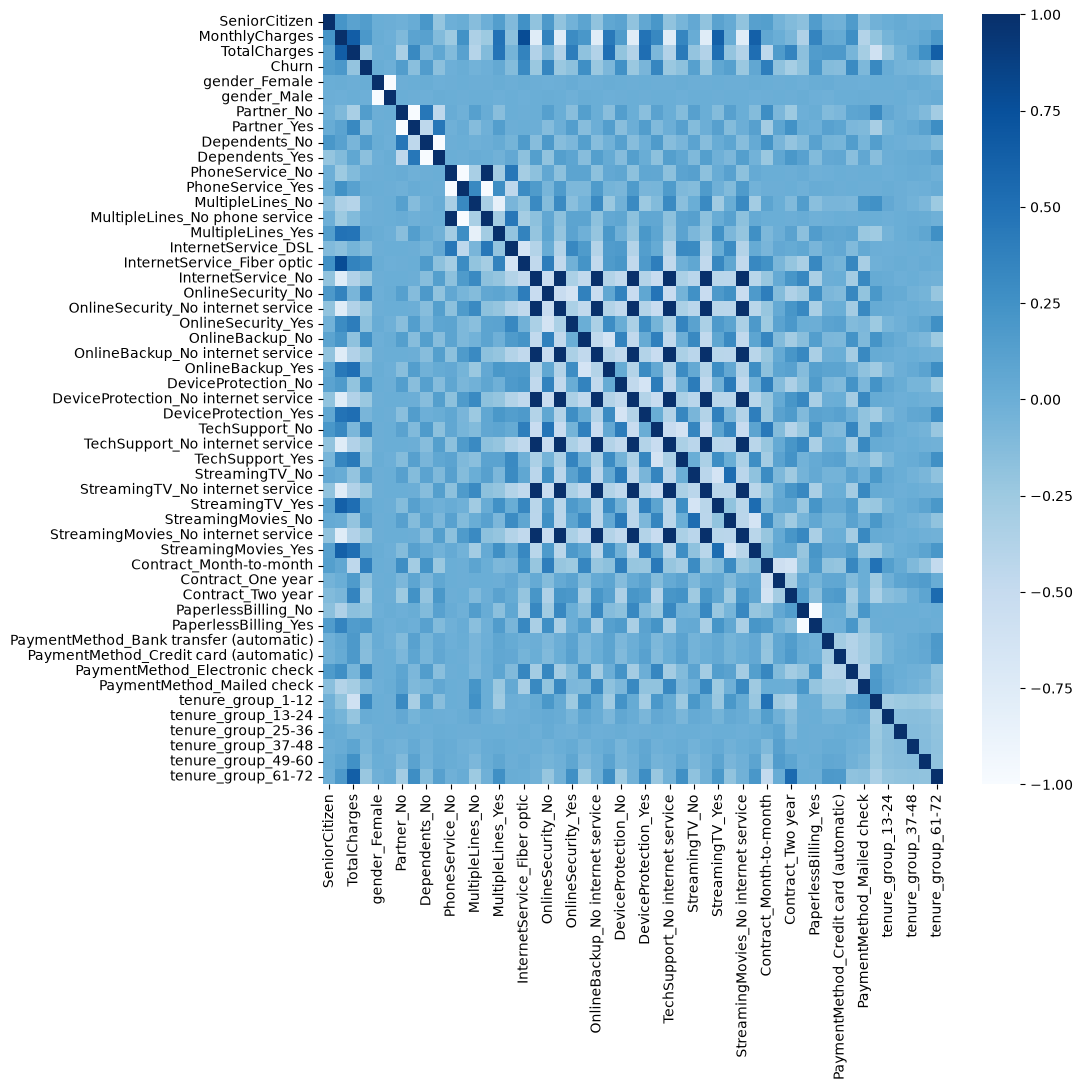

In [51]:
plt.figure(figsize=(10,10))
sns.heatmap(telco_data_dummies.corr(),cmap='Blues')

### Bivariate Analysis

In [52]:
new_df_target0=telco_data.loc[telco_data['Churn']==0]
new_df_target1=telco_data.loc[telco_data['Churn']==1]

In [62]:
def plot_count(df,column,hue=None):
    plt.figure(figsize=(10,6))
    sns.countplot(x=column,data=df,hue=hue)
    plt.title(f" {column} Distribution")
    plt.xticks(rotation=45,fontsize=10)
    plt.show()


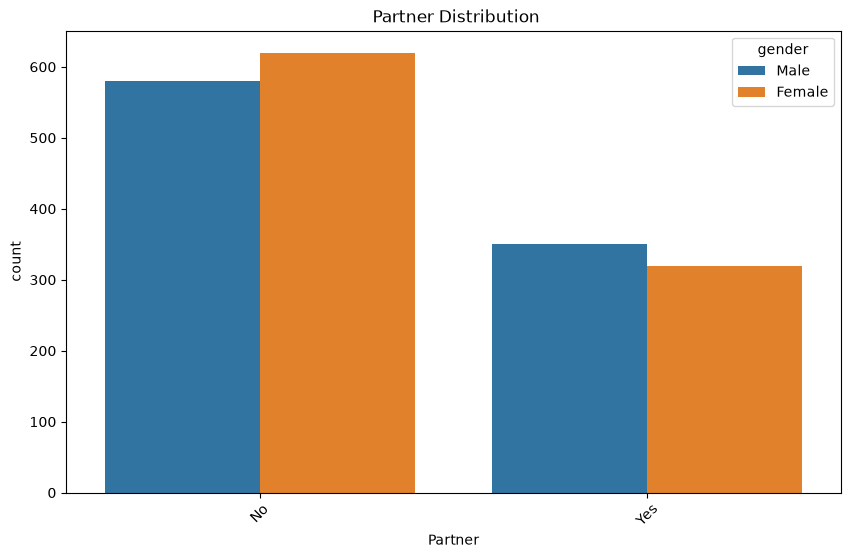

In [65]:
plot_count(new_df_target1,'Partner','gender')

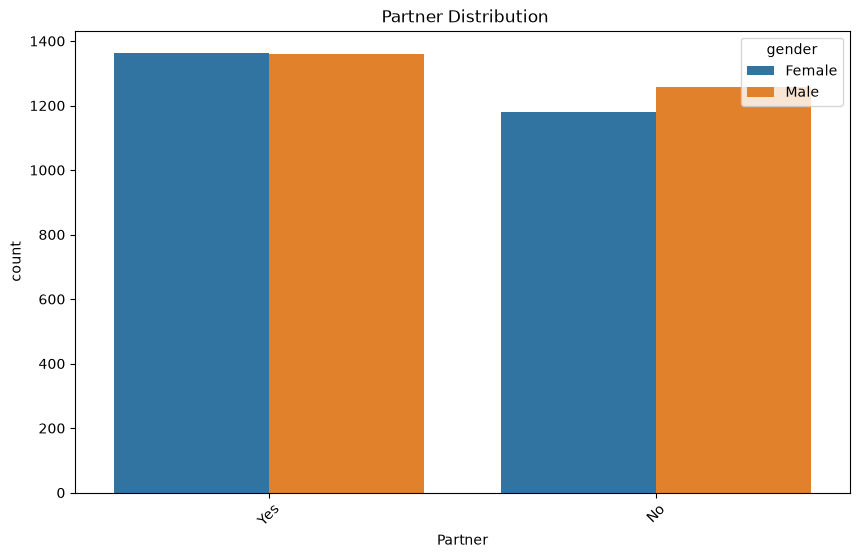

In [66]:
plot_count(new_df_target0,'Partner','gender')

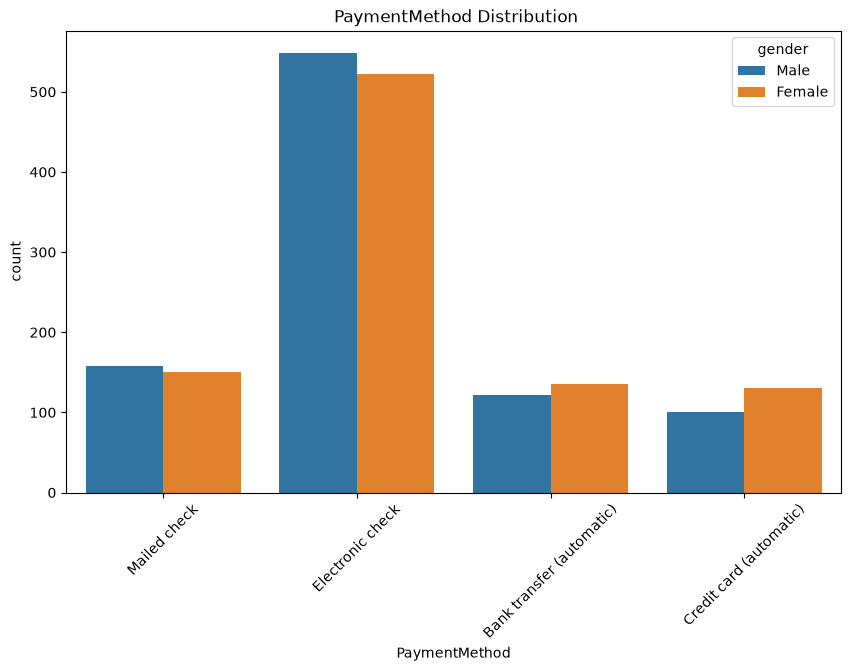

In [67]:
plot_count(new_df_target1,'PaymentMethod','gender')

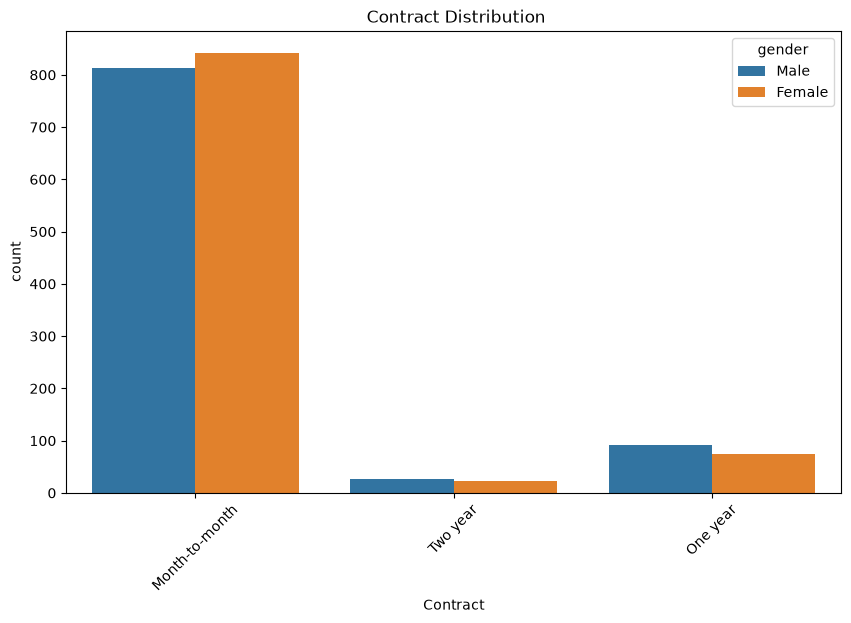

In [69]:
plot_count(new_df_target1,'Contract','gender')

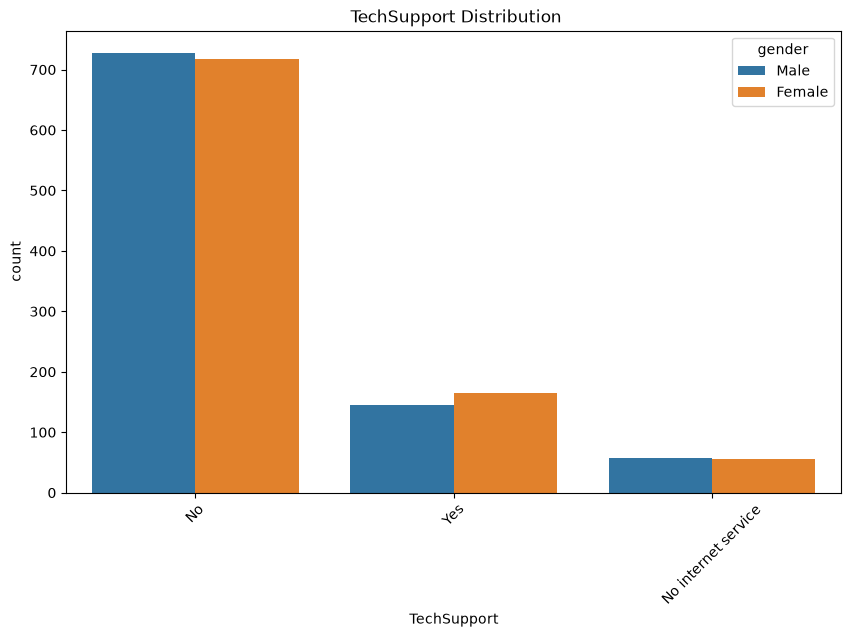

In [70]:
plot_count(new_df_target1,'TechSupport','gender')

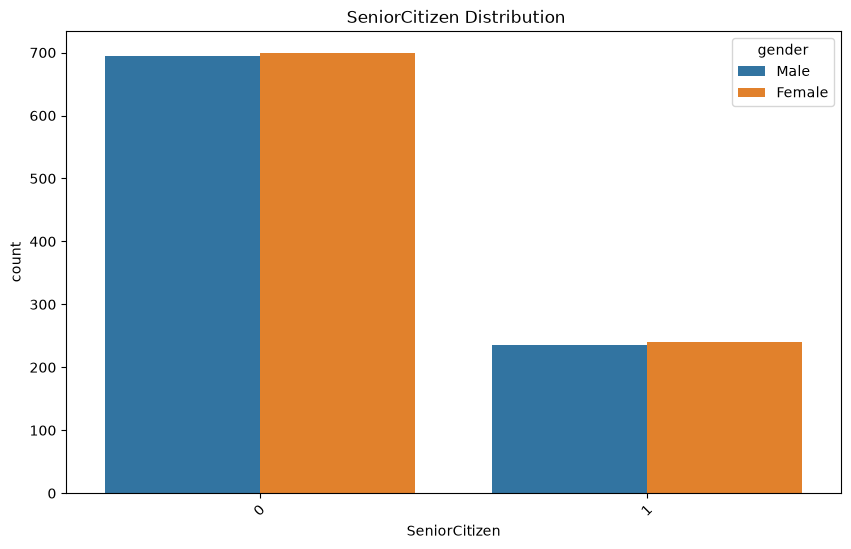

In [72]:
plot_count(new_df_target1,'SeniorCitizen','gender')

## Key Findings from EDA

- Electronic Check is the most common payment method among churned customers.
- Customers on Month-to-Month contracts exhibit the highest churn, suggesting that flexible contracts are associated with lower customer retention.
- Lack of Online Security and Tech Support services is strongly associated with higher churn.
- The majority of churned customers are Non-Senior Citizens.
- These insights indicate that **Contract Type**, **Payment Method**, and **Value-Added Services** are important factors influencing customer churn and should be considered during model development.